In [ ]:
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.lines import Line2D
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd
import glob
import os
from datetime import datetime, timedelta
import seaborn as sns

ERROR 1: PROJ: proj_create_from_database: Open of /g/data/xp65/public/./apps/med_conda/envs/analysis3-25.09/share/proj failed


Plot the probability density function (PDF) distibution of selected heat indicators for all spatial points in selected time periods - Figures 11 and S17

In [3]:
# mask
lat_min, lat_max = -34.14, -33.55
lon_min, lon_max = 150.57, 151.37

# using any scenario but the bulk
file_luindex = "/g/data/fy29/mf9078/run_WRF/etamodified/output/4out/animation/wrfout_d02_2017-01-12_21:00:00"
ds_mask = xr.open_dataset(file_luindex) 
XLAT = ds_mask["XLAT"]
XLONG = ds_mask["XLONG"]
LU_INDEX = ds_mask["LU_INDEX"] 
lat_mask = (XLAT >= lat_min) & (XLAT <= lat_max)
lon_mask = (XLONG >= lon_min) & (XLONG <= lon_max)
lu_mask = (LU_INDEX >= 51) & (LU_INDEX <= 60)
region_mask = lat_mask & lon_mask & lu_mask
ds_mask.close()

print(f"Region mask covers {region_mask.sum().values} grid points")

Region mask covers 1629 grid points


In [4]:
# Data processing for each diurnal period
paths = {
    "LCZ": "/g/data/fy29/mf9078/run_WRF/etamodified/output/1out/animation/",
    "WSF-MB": "/g/data/fy29/mf9078/run_WRF/etamodified/output/3out/animation/",
    "Geoscape": "/g/data/fy29/mf9078/run_WRF/etamodified/output/4out/animation/"
}

time_periods = {
    "Before Sunrise": (2, 5),
    "Morning": (7, 10),
    "Peak Solar": (11, 14),
    "Afternoon": (15, 18),
    "Evening": (19, 22)
}

# Dictionary to store all wind data for each scenario and time period
scenario_period_data = {}

for scenario_name in paths.keys():
    scenario_period_data[scenario_name] = {}
    for period_name in time_periods.keys():
        scenario_period_data[scenario_name][period_name] = {
            'COMF90': [],
            'COMF10': [],
            'T2': []
        }

# Function to determine time period from AEST hour
def get_time_period(hour_aest):
    for period_name, (start_hour, end_hour) in time_periods.items():
        if start_hour <= hour_aest <= end_hour:
            return period_name
    return None

for scenario_name, path in paths.items():
    print(f"\nProcessing {scenario_name}...")
    
    file_pattern = os.path.join(path, "wrfout_d02_2017-01-*")
    file_list = sorted(glob.glob(file_pattern))
    print(f"Found {len(file_list)} files for {scenario_name}")
    
    for i, file_path in enumerate(file_list):
        try:
            # Extract time from filename and convert to AEST
            timestamp_utc = datetime.strptime(os.path.basename(file_path)[11:], "%Y-%m-%d_%H:%M:%S")
            timestamp_aest = timestamp_utc + timedelta(hours=10)
            hour_aest = timestamp_aest.hour
            
            # Determine which time period this file belongs to
            period_name = get_time_period(hour_aest)
            
            if period_name is None:
                continue  # Skip files that don't fall in any defined period
            
            ds = xr.open_dataset(file_path)
            
            # Calculate wind speed and direction
            T2 = ds["T2"] - 273.15
            COMF90 = ds["COMF_90"]
            COMF10 = ds["COMF_10"]
            
            # Apply mask
            T2_masked = T2.where(region_mask).values
            COMF90_masked = COMF90.where(region_mask).values
            COMF10_masked = COMF10.where(region_mask).values
            
            valid_mask = ~np.isnan(T2_masked)
            COMF90_valid = COMF90_masked[valid_mask]
            COMF10_valid = COMF10_masked[valid_mask]
            T2_valid = T2_masked[valid_mask]
            
            # Collect data for the appropriate time period
            scenario_period_data[scenario_name][period_name]['COMF90'].append(COMF90_valid)
            scenario_period_data[scenario_name][period_name]['COMF10'].append(COMF10_valid)
            scenario_period_data[scenario_name][period_name]['T2'].append(T2_valid)
            
            ds.close()
        
        except Exception as e:
            print(f"Error processing {file_path}: {e}")
            continue

# Combine data for each scenario-period combination
for scenario_name in paths.keys():
    for period_name in time_periods.keys():
        T2_list = scenario_period_data[scenario_name][period_name]['T2']
        COMF90_list = scenario_period_data[scenario_name][period_name]['COMF90']
        COMF10_list = scenario_period_data[scenario_name][period_name]['COMF10']
        
        if T2_list:
            combined_T2 = np.concatenate(T2_list)
            combined_COMF90 = np.concatenate(COMF90_list)
            combined_COMF10 = np.concatenate(COMF10_list)

            # Apply UTCI range mask for COMF90 and COMF10 (0-100 range)
            # Filter COMF90: keep only values between 0-100
            utci_mask_90 = (combined_COMF90 >= 0) & (combined_COMF90 <= 100)
            combined_COMF90_filtered = combined_COMF90[utci_mask_90]
            
            # Filter COMF10: keep only values between 0-100
            utci_mask_10 = (combined_COMF10 >= 0) & (combined_COMF10 <= 100)
            combined_COMF10_filtered = combined_COMF10[utci_mask_10]
            
            # Store the filtered data
            scenario_period_data[scenario_name][period_name]['T2'] = combined_T2
            scenario_period_data[scenario_name][period_name]['COMF90'] = combined_COMF90_filtered
            scenario_period_data[scenario_name][period_name]['COMF10'] = combined_COMF10_filtered
            
            print(f"{scenario_name} - {period_name}: T2: {len(combined_T2)}, COMF90: {len(combined_COMF90_filtered)}, COMF10: {len(combined_COMF10_filtered)} data points")
        else:
            # No data for this combination
            scenario_period_data[scenario_name][period_name]['T2'] = np.array([])
            scenario_period_data[scenario_name][period_name]['COMF90'] = np.array([])
            scenario_period_data[scenario_name][period_name]['COMF10'] = np.array([])
            print(f"{scenario_name} - {period_name}: No data points")


Processing LCZ...
Found 241 files for LCZ

Processing WSF-MB...
Found 241 files for WSF-MB

Processing Geoscape...
Found 241 files for Geoscape
LCZ - Before Sunrise: T2: 65160, COMF90: 65160, COMF10: 65160 data points
LCZ - Morning: T2: 65160, COMF90: 65160, COMF10: 65160 data points
LCZ - Peak Solar: T2: 65160, COMF90: 65160, COMF10: 65160 data points
LCZ - Afternoon: T2: 65160, COMF90: 65160, COMF10: 65160 data points
LCZ - Evening: T2: 65160, COMF90: 65160, COMF10: 65160 data points
WSF-MB - Before Sunrise: T2: 65160, COMF90: 65093, COMF10: 64883 data points
WSF-MB - Morning: T2: 65160, COMF90: 65084, COMF10: 64857 data points
WSF-MB - Peak Solar: T2: 65160, COMF90: 65036, COMF10: 64725 data points
WSF-MB - Afternoon: T2: 65160, COMF90: 65013, COMF10: 64638 data points
WSF-MB - Evening: T2: 65160, COMF90: 65035, COMF10: 64717 data points
Geoscape - Before Sunrise: T2: 65160, COMF90: 65160, COMF10: 65160 data points
Geoscape - Morning: T2: 65160, COMF90: 65160, COMF10: 65160 data po

/scratch/pu02/mf9078/tmp/ipykernel_389669/2630181745.py:125: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


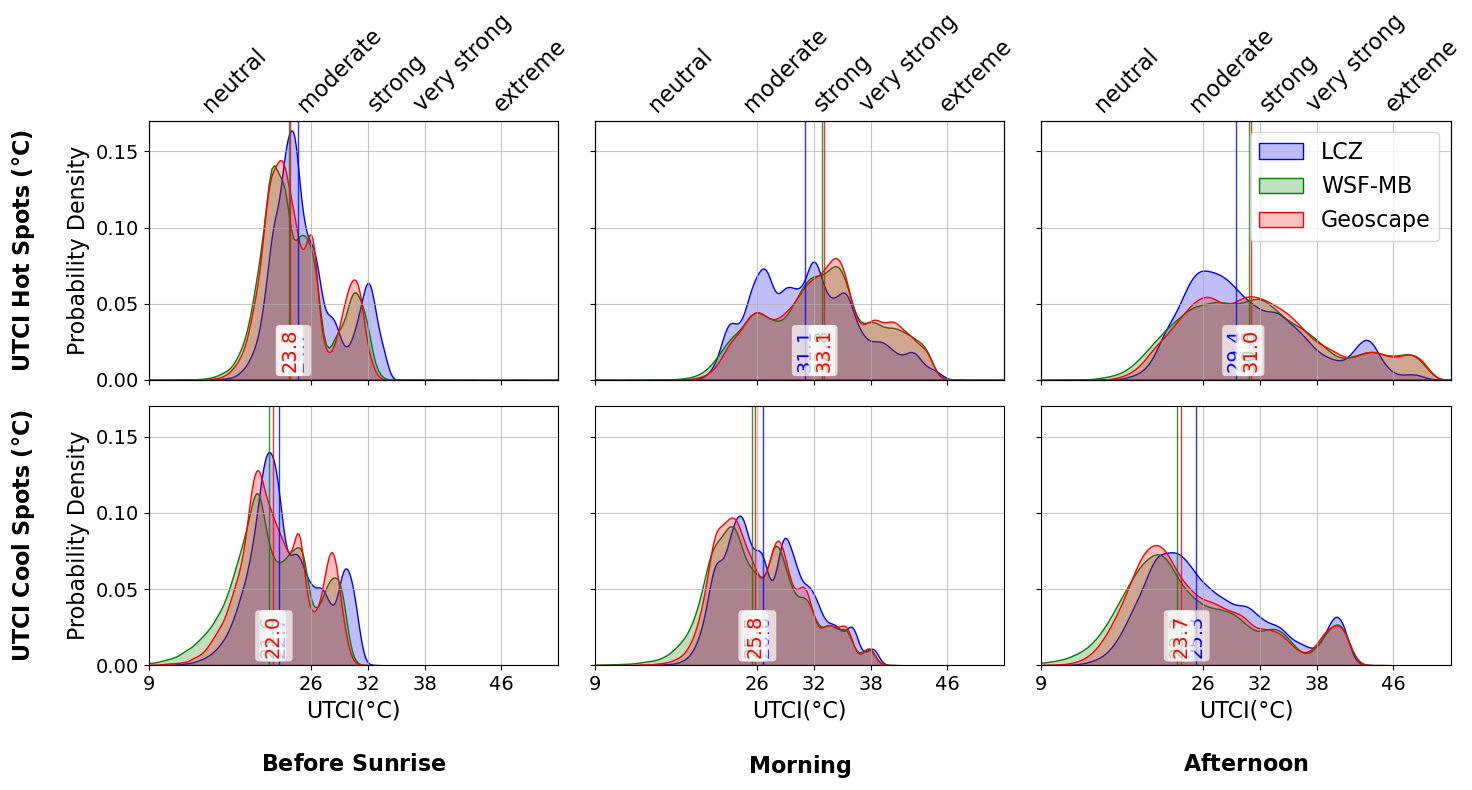

In [ ]:
#PDF of UTCI hot and cool spots before sunrise, in the morning and afternoon - Fig 11
# Colors assigned to each label
colors = {
    "LCZ": "blue",
    "WSF-MB": "green",
    "Geoscape": "red"
}

# Variables to plot
variables = {
    "COMF90": {
        "label": "UTCI Hot Spots (°C)",
        "xlim": (9, 52),
        "ylim": (0, 0.17),
        "row_idx": 0
    },
    "COMF10": {
        "label": "UTCI Cool Spots (°C)",
        "xlim": (9, 52),
        "ylim": (0, 0.17),
        "row_idx": 1
    }
}

# Diurnal periods - subset of 3 periods
periods = ['Before Sunrise', 'Morning', 'Afternoon']

# UTCI heat stress categories
utci_ticks = [9, 26, 32, 38, 46]
utci_labels = ['moderate', 'strong', 'very strong', 'extreme']

# Category label positions (midpoints of ranges)
category_positions = [18, 29, 35, 42, 49]  # neutral, moderate, strong, very strong, extreme
category_labels = ['neutral', 'moderate', 'strong', 'very strong', 'extreme']

# Set up subplots - 2 rows (variables) x 3 columns (periods)
fig, axs = plt.subplots(nrows=2, ncols=3, sharey=True, figsize=(15, 8), constrained_layout=True)

# Create plots
for varname, var_props in variables.items():
    row_idx = var_props["row_idx"]
    
    for col_idx, period_name in enumerate(periods):
        ax = axs[row_idx, col_idx]
        
        # Plot for each scenario
        for scenario_name in ["LCZ", "WSF-MB", "Geoscape"]:
            # Get data for this specific period, variable, and scenario
            data = scenario_period_data[scenario_name][period_name][varname]
            
            # Check if we have valid data
            if len(data) > 0:
                sns.kdeplot(data, label=scenario_name, color=colors[scenario_name], 
                           fill=True, common_norm=False, ax=ax)
                
                # Median line
                median_val = np.median(data)
                ax.axvline(median_val, color=colors[scenario_name], 
                          linestyle="-", linewidth=1, alpha=0.8)
                
                # Median label
                ax.text(
                    median_val, 0.005, f"{median_val:.1f}",
                    color=colors[scenario_name], ha="center", va="bottom", 
                    fontsize=14, rotation=90,  
                    bbox=dict(boxstyle="round,pad=0.2", edgecolor='none', 
                             facecolor='white', alpha=0.7)
                )
            else:
                # If no valid data, add empty plot for legend
                ax.plot([], [], color=colors[scenario_name], label=scenario_name, linewidth=6)
                print(f"Warning: No valid data for {scenario_name} {varname} {period_name}")
        
        # Axis and layout
        ax.set_xlim(*var_props["xlim"])
        ax.set_ylim(*var_props["ylim"])
        ax.grid(True, linestyle="--", alpha=0.4)
        
        # Add variable label on the left side for the first column
        if col_idx == 0:
            label = var_props['label'].replace(" ", "\\ ")
            ax.set_ylabel(f"$\\mathbf{{{label}}}$\n\nProbability Density", fontsize=16)
        else:
            # No y-axis label for other columns
            ax.set_ylabel("")
        
        # Set tick label fontsize
        ax.tick_params(axis='both', which='major', labelsize=14)
        
        # X-axis label only for bottom row
        if row_idx == 1:
            # Replace spaces with "\ " to preserve them in LaTeX math mode
            period_latex = period_name.replace(" ", "\\ ")
            ax.set_xlabel(f"UTCI(°C)\n\n$\\mathbf{{{period_latex}}}$", fontsize=16)
        else:
            ax.set_xlabel("")
            ax.tick_params(labelbottom=False)
        
        # UTCI-specific formatting
        ax.set_xticks(utci_ticks)
        ax.set_xticklabels(utci_ticks)
        
        # Create secondary x-axis for category labels (only for top row)
        if row_idx == 0:
            ax2 = ax.twiny()
            ax2.set_xlim(9, 52)  # Match the main axis limits
            # Set category labels at their midpoint positions
            ax2.set_xticks(category_positions)
            ax2.set_xticklabels(category_labels, fontsize=16, rotation=45)
            # Remove tick marks for cleaner appearance
            ax2.tick_params(length=0)
        
        # Turn off minor gridlines for UTCI plots
        ax.grid(True, which='major', linestyle='-', alpha=0.7)
        ax.grid(False, which='minor')
        
        # Add legend only to the top-right subplot
        if row_idx == 0 and col_idx == 2:
            ax.legend(loc="upper right", fontsize=16)

# Adjust layout and save
plt.tight_layout()
plt.savefig("PDF_diurnal_periods_2x3.png", 
           dpi=300, bbox_inches='tight')
plt.show()

/scratch/pu02/mf9078/tmp/ipykernel_389669/1984570970.py:133: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


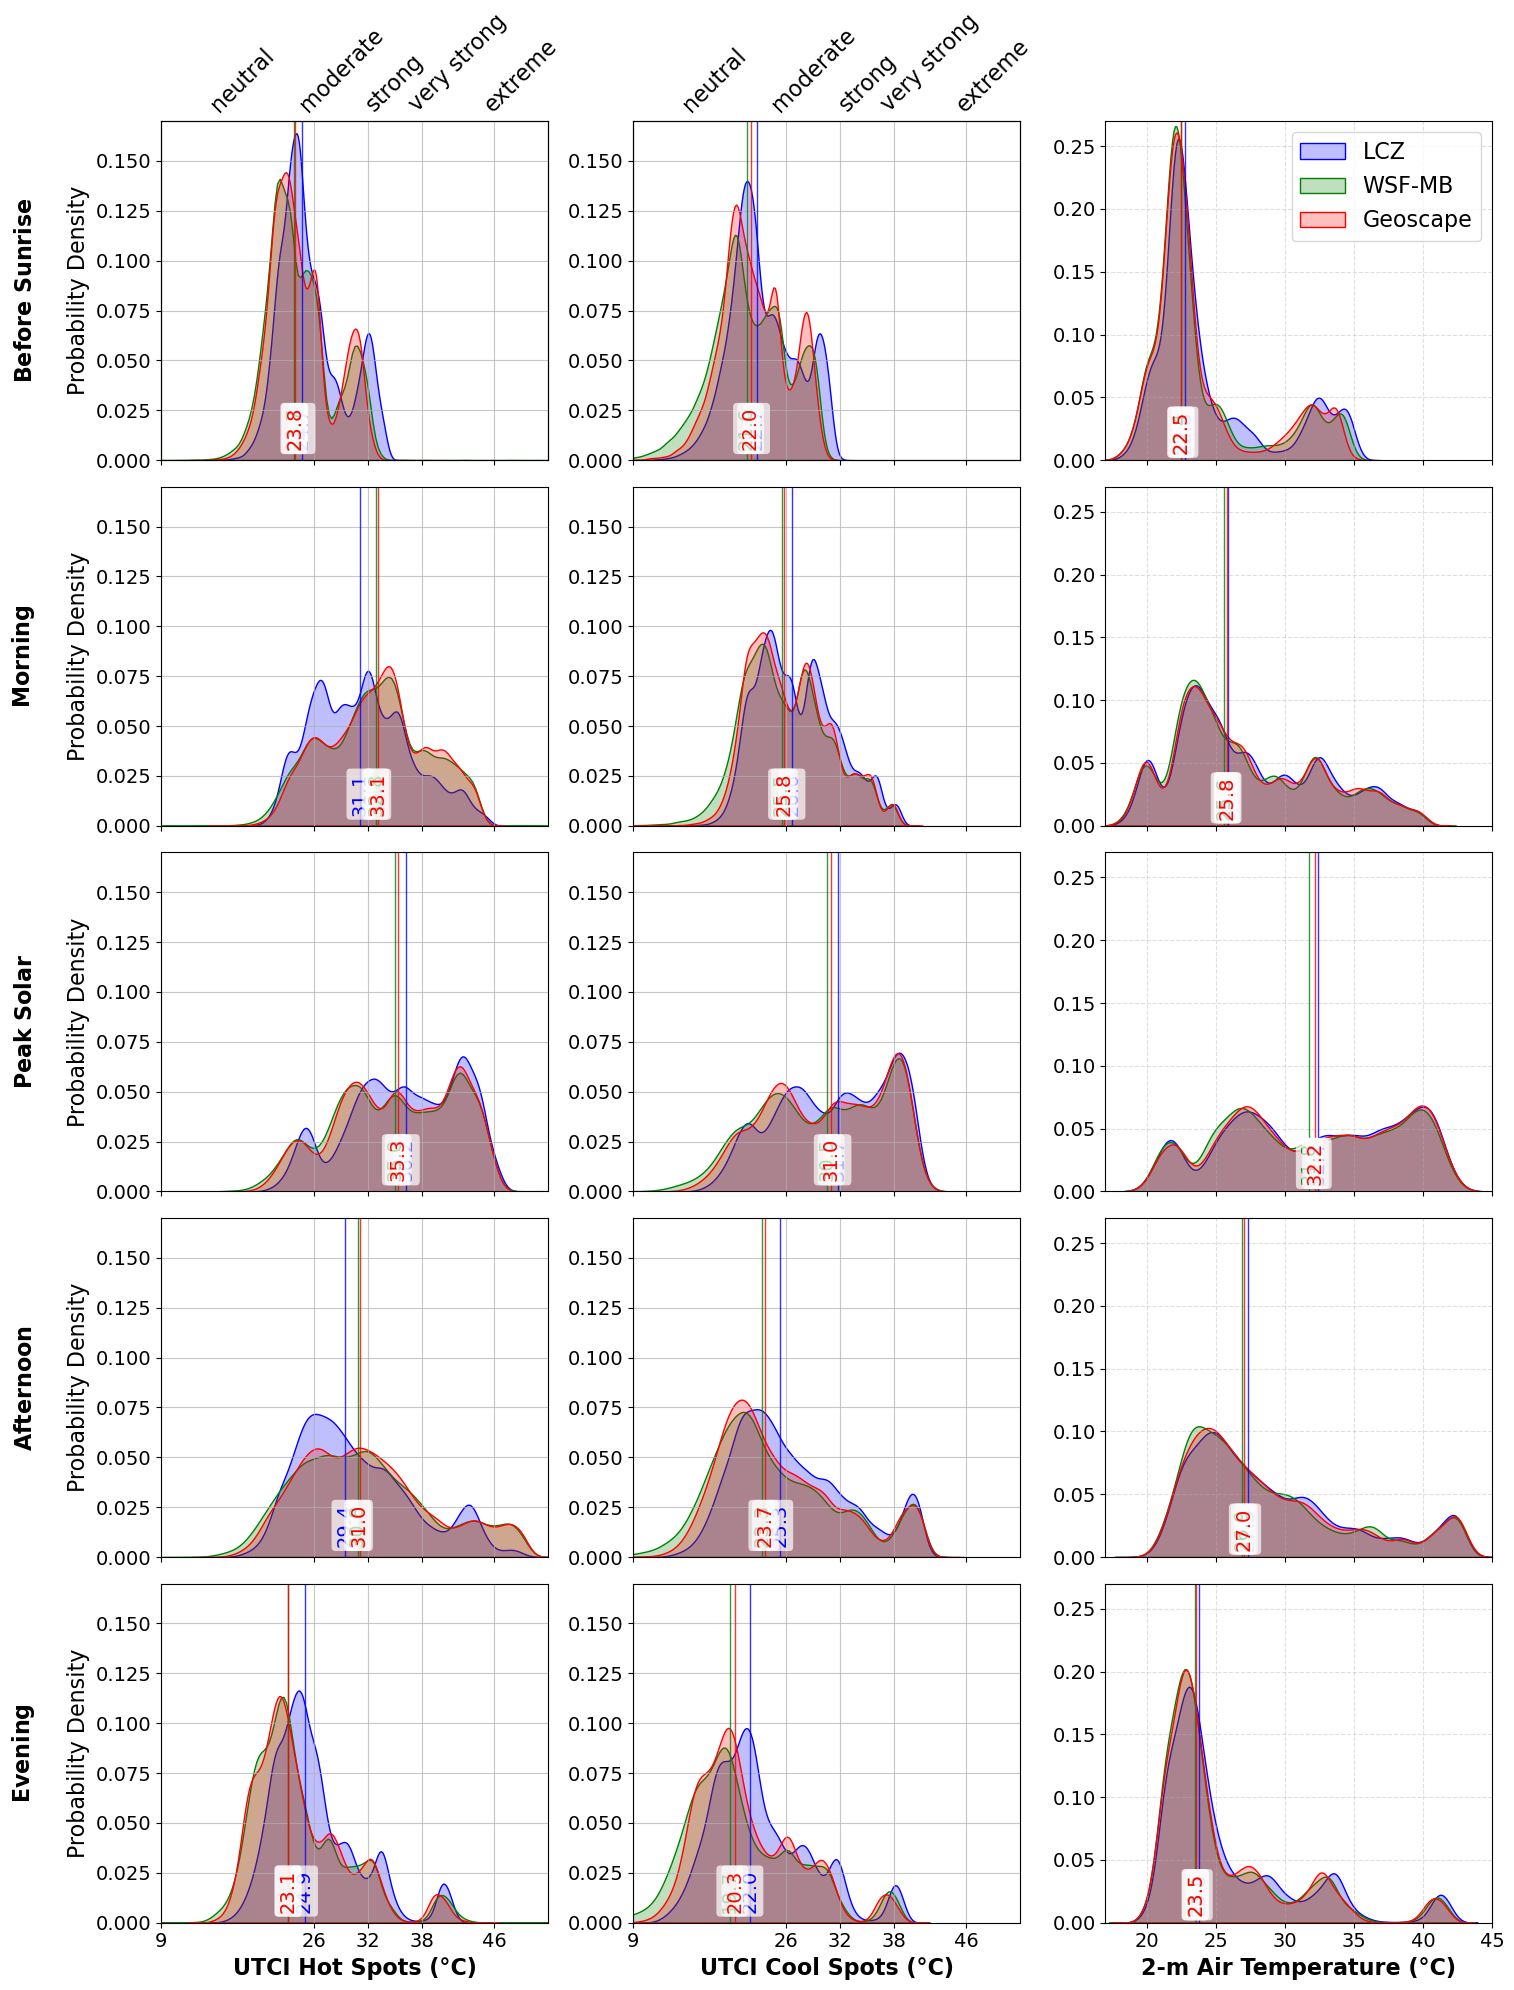

In [ ]:
#PDF of temperature, UTCI hot and cool spots for all the 5 time periods - Fig S17

# Colors assigned to each label
colors = {
    "LCZ": "blue",
    "WSF-MB": "green",
    "Geoscape": "red"
}

# Variables to plot
variables = {
    "COMF90": {
        "label": "UTCI Hot Spots (°C)",
        "xlim": (9, 52),
        "ylim": (0, 0.17),  # Added y-limit
        "col_idx": 0
    },
    "COMF10": {
        "label": "UTCI Cool Spots (°C)",
        "xlim": (9, 52),
        "ylim": (0, 0.17),  # Added y-limit
        "col_idx": 1
    },
    "T2": {
        "label": "2-m Air Temperature (°C)",
        "xlim": (17, 45),
        "ylim": (0, 0.27),  # Added y-limit
        "col_idx": 2
    }
}

# Diurnal periods
periods = ['Before Sunrise', 'Morning', 'Peak Solar', 'Afternoon', 'Evening']

# UTCI heat stress categories
utci_ticks = [9, 26, 32, 38, 46]
utci_labels = ['moderate', 'strong', 'very strong', 'extreme']

# Category label positions (midpoints of ranges)
category_positions = [18, 29, 35, 42, 49]  # neutral, moderate, strong, very strong, extreme
category_labels = ['neutral', 'moderate', 'strong', 'very strong', 'extreme']

# Set up subplots - 5 rows (periods) x 3 columns (variables)
fig, axs = plt.subplots(nrows=5, ncols=3, figsize=(15, 20), constrained_layout=True)

# Create plots
for row_idx, period_name in enumerate(periods):
    for varname, var_props in variables.items():
        col_idx = var_props["col_idx"]
        ax = axs[row_idx, col_idx]
        
        # Plot for each scenario
        for scenario_name in ["LCZ", "WSF-MB", "Geoscape"]:
            # Get data for this specific period, variable, and scenario
            data = scenario_period_data[scenario_name][period_name][varname]
            
            # Check if we have valid data
            if len(data) > 0:
                sns.kdeplot(data, label=scenario_name, color=colors[scenario_name], 
                           fill=True, common_norm=False, ax=ax)
                
                # Median line
                median_val = np.median(data)
                ax.axvline(median_val, color=colors[scenario_name], 
                          linestyle="-", linewidth=1, alpha=0.8)
                
                # Median label
                ax.text(
                    median_val, 0.005, f"{median_val:.1f}",
                    color=colors[scenario_name], ha="center", va="bottom", 
                    fontsize=14, rotation=90,  
                    bbox=dict(boxstyle="round,pad=0.2", edgecolor='none', 
                             facecolor='white', alpha=0.7)
                )
            else:
                # If no valid data, add empty plot for legend
                ax.plot([], [], color=colors[scenario_name], label=scenario_name, linewidth=6)
                print(f"Warning: No valid data for {scenario_name} {varname} {period_name}")
        
        # Axis and layout
        ax.set_xlim(*var_props["xlim"])
        ax.set_ylim(*var_props["ylim"])  # Set y-axis limits
        ax.grid(True, linestyle="--", alpha=0.4)
        
        # Add period label on the left side for the first column
        if col_idx == 0:
            # Replace spaces with "\ " to preserve them in LaTeX math mode
            period_latex = period_name.replace(" ", "\\ ")
            ax.set_ylabel(f"$\\mathbf{{{period_latex}}}$\n\nProbability Density", fontsize=16)
        else:
            # No y-axis label for other columns
            ax.set_ylabel("")
        
        
        # Set tick label fontsize to 12 for all axes
        ax.tick_params(axis='both', which='major', labelsize=14)

        # X-axis label only for bottom row
        if row_idx == 4:
            ax.set_xlabel(var_props["label"], fontweight='bold', fontsize=16)
        else:
            ax.set_xlabel("")
            ax.tick_params(labelbottom=False)
        
        # UTCI-specific formatting for COMF90 and COMF10
        if varname in ["COMF90", "COMF10"]:
            ax.set_xticks(utci_ticks)
            ax.set_xticklabels(utci_ticks)
            
            # Create secondary x-axis for category labels (only for top row)
            if row_idx == 0:
                ax2 = ax.twiny()
                ax2.set_xlim(9, 52)  # Match the main axis limits
                # Set category labels at their midpoint positions
                ax2.set_xticks(category_positions)
                ax2.set_xticklabels(category_labels, fontsize=16,  rotation=45)
                #ax2.set_xlabel('Heat Stress Category', fontsize=10)
                # Remove tick marks for cleaner appearance
                ax2.tick_params(length=0)
            
            # Turn off minor gridlines for UTCI plots
            ax.grid(True, which='major', linestyle='-', alpha=0.7)
            ax.grid(False, which='minor')
        
        # Add legend only to the top-right subplot
        if row_idx == 0 and col_idx == 2:
            ax.legend(loc="upper right", fontsize=16)

# Adjust layout and save
plt.tight_layout()
plt.savefig("PDF_diurnal_periods_5x3.png", 
           dpi=300, bbox_inches='tight')
plt.show()